<style>
.jp-RenderedHTMLCommon,
.text_cell_render {
  font-family: medium-content-serif-font, Georgia, Cambria, "Times New Roman", Times, serif;
  font-size: 17px;
  line-height: 1.65;
  color: #1f2328;
}
.jp-RenderedHTMLCommon h1,
.jp-RenderedHTMLCommon h2,
.jp-RenderedHTMLCommon h3,
.text_cell_render h1,
.text_cell_render h2,
.text_cell_render h3 {
  font-family: sohne, "Helvetica Neue", Helvetica, Arial, sans-serif;
  color: #111;
}
.jp-RenderedHTMLCommon h1,
.text_cell_render h1 {
  font-size: 2.6rem;
  letter-spacing: -0.03em;
}
.jp-RenderedHTMLCommon h2,
.text_cell_render h2 {
  margin-top: 1.8em;
}
</style>

# Expediente C. Contratación atípica

Data Analytics | Semanas 7–8 | 2026-2

Este notebook acompaña la lectura ¿Qué puede decir realmente un contrato público?

Afirmación que se investigará:

Algunas entidades presentan patrones contractuales diferentes al resto que justifican una revisión adicional.

Este expediente utiliza un único archivo: `data/secop_recorte.csv`.

Durante la primera semana se construyen tres evidencias y se documentan tres decisiones de preparación. En la segunda semana se incorpora una objeción y se revisa si la conclusión inicial se mantiene.

El objetivo es que cada cifra utilizada en la conclusión pueda localizarse en el notebook y que el alcance de la afirmación corresponda a lo que realmente muestran los datos.


## Preparar los datos

Ubique el notebook junto a la carpeta `data`.

```text
Expediente_C.ipynb
data/
└── secop_recorte.csv
```

No es necesario descargar datos, seleccionar un equipo ni modificar filtros.


In [ ]:
%pip install numpy pandas matplotlib

In [3]:
from pathlib import Path
from statistics import NormalDist
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from google.colab import files

uploaded = files.upload()

DATA_FILE = Path("secop_recorte.csv")

if not DATA_FILE.exists():
    raise FileNotFoundError("No se encontró secop_recorte.csv.")

df_raw = pd.read_csv(DATA_FILE, dtype=str)

print("Archivo:", DATA_FILE.name)
print("Filas:", f"{len(df_raw):,}")
print("Columnas:", df_raw.shape[1])

Saving secop_recorte.csv to secop_recorte.csv
Archivo: secop_recorte.csv
Filas: 50,000
Columnas: 85


### Criterio previo del equipo
Consideraremos indicio de atipicidad estadística en una entidad:
1. Una proporción de contratación directa sobre su total claramente mayor que la de sus pares.
2. Una concentración temporal alta de firmas (por ejemplo, un porcentaje elevado de sus contratos firmados en un solo mes) frente a sus pares.

Pares: entidades del mismo orden (territorial, nacional o corporación autónoma) con al menos 30 contratos en el recorte.

Un patrón atípico se leerá como criterio para priorizar una revisión, no como evidencia de irregularidad: puede tener explicaciones legítimas, como la naturaleza misional de la entidad o un régimen de contratación especial.

## Comprender el archivo antes de analizarlo

Cada fila de `secop_recorte.csv` representa un contrato incluido en el conjunto asignado al equipo. El archivo no corresponde a todo SECOP II, sino a una parte previamente seleccionada para la actividad.

La columna `ciudad`, cuando está disponible, identifica la ciudad de registro de la entidad que publica el contrato. No debe interpretarse automáticamente como el lugar físico donde se ejecutó el servicio, la obra o el suministro.

Las siguientes conversiones permiten trabajar con valores y fechas sin eliminar registros.


In [4]:
df = df_raw.copy()

for column in ["valor_del_contrato", "dias_adicionados"]:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

for column in [
    "fecha_de_firma",
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
]:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors="coerce")

if {
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
}.issubset(df.columns):
    df["duracion_dias"] = (
        df["fecha_de_fin_del_contrato"]
        - df["fecha_de_inicio_del_contrato"]
    ).dt.days

if {"valor_del_contrato", "duracion_dias"}.issubset(df.columns):
    months = df["duracion_dias"] / 30.44
    df["valor_mensual_equivalente"] = (
        df["valor_del_contrato"] / months.where(months > 0)
    )

sample_columns = [
    c for c in [
        "id_contrato",
        "nombre_entidad",
        "ciudad",
        "proveedor_adjudicado",
        "tipo_de_contrato",
        "modalidad_de_contratacion",
        "valor_del_contrato",
        "fecha_de_firma",
    ]
    if c in df.columns
]

df[sample_columns].head()


,id_contrato,nombre_entidad,ciudad,proveedor_adjudicado,tipo_de_contrato,modalidad_de_contratacion,valor_del_contrato,fecha_de_firma
0,CO1.PCCNTR.6994937,DANE - TERRITORIAL CENTRO ORIENTE,Bucaramanga,KAREN ANDREA SILVA DUARTE,Prestación de servicios,Contratación directa,6190750.0,2024-11-06
1,CO1.PCCNTR.7964038,METROLINEA S.A,Bucaramanga,servicios electroindustriales arg de santander...,Prestación de servicios,Contratación régimen especial,131589110.0,2025-06-10
2,CO1.PCCNTR.8395876,"INSTITUTO PARA EL FOMENTO DEL DEPORTE, LA RECR...",Barrancabermeja,CESAR ANDRES SIERRA BELTRAN,Prestación de servicios,Contratación directa,6250000.0,2025-10-01
3,CO1.PCCNTR.6217730,UNIDAD PRESTADORA DE SALUD SANTANDER,Bucaramanga,TATIANA ANDREA PLATA CEPEDA,Prestación de servicios,Contratación directa,11821128.0,2024-05-14
4,CO1.PCCNTR.8589375,DEPARTAMENTO DE SANTANDER,Bucaramanga,LUZ JEANETH ROJAS TARAZONA,Prestación de servicios,Contratación directa,46400000.0,2025-11-13


### Respuestas a "Antes de seguir"

**1. ¿Qué representa una fila?**
Cada fila es un contrato registrado en SECOP II dentro del recorte asignado (Santander, 2024-2025). El archivo tiene 50.000 filas y 50.000 identificadores de contrato distintos, así que contar filas equivale a contar contratos, no personas ni proveedores.

**2. ¿Qué información permite identificar a la entidad y al proveedor?**
La entidad se identifica con `nombre_entidad` y con su NIT (`nit_entidad`). El proveedor se identifica con `proveedor_adjudicado` (nombre) y `documento_proveedor` (número de documento). El documento es más confiable que el nombre, porque un mismo nombre puede escribirse de varias formas.

**3. ¿Qué variable monetaria aparece en el archivo?**
`valor_del_contrato`, el valor total registrado del contrato. El archivo también trae otras columnas de dinero (como `valor_pagado` y `valor_facturado`), pero el análisis usa el valor total.

**4. ¿Qué variable o columna necesita comprender mejor?**
`ciudad`. Es la ciudad donde está registrada la entidad que publica el contrato, no necesariamente donde se ejecuta el trabajo. Además, muchas filas dicen "No Definido", un dato faltante que no aparece como vacío. Antes de usarla, hay que definir cómo tratarlo.


## Primera semana: describir el conjunto asignado

La primera revisión se concentra en `valor_del_contrato`. Se estudiará una variable por separado antes de introducir comparaciones entre grupos.

La media, la mediana y los percentiles no responden exactamente la misma pregunta. Si la distribución contiene unos pocos contratos de valor muy alto, la media puede alejarse considerablemente de la mediana.


### E1 — Distribución del valor contractual

In [5]:
if "valor_del_contrato" not in df.columns:
    raise KeyError("El archivo no contiene la columna valor_del_contrato.")

contract_value = df["valor_del_contrato"].dropna()

value_summary = pd.Series({
    "contratos con valor registrado": len(contract_value),
    "media": contract_value.mean(),
    "mediana": contract_value.median(),
    "percentil 25": contract_value.quantile(0.25),
    "percentil 75": contract_value.quantile(0.75),
    "percentil 90": contract_value.quantile(0.90),
    "mínimo": contract_value.min(),
    "máximo": contract_value.max(),
    "contratos con valor 0": int((contract_value == 0).sum()),
})

value_summary.to_frame("resultado")


,resultado
contratos con valor registrado,5.000000e+04
media,9.906600e+07
mediana,1.500000e+07
percentil 25,8.775000e+06
percentil 75,2.700000e+07
percentil 90,4.986686e+07
mínimo,0.000000e+00
máximo,2.000000e+11
contratos con valor 0,2.790000e+02


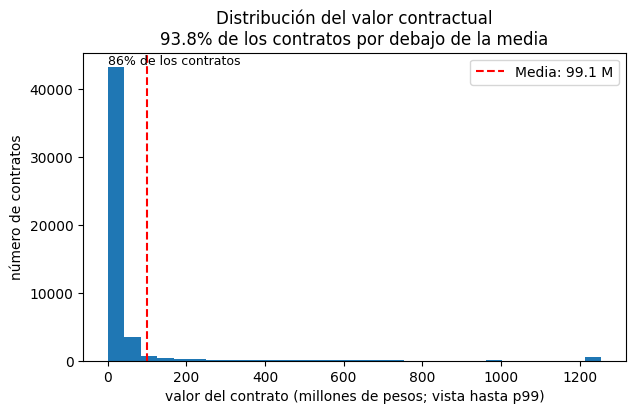

Porcentaje de contratos por debajo de la media: 93.8%
Porcentaje de contratos en la primera barra: 86.3%


In [6]:
upper_view = contract_value.quantile(0.99)
values_view = contract_value.clip(upper=upper_view) / 1_000_000
mean_millions = contract_value.mean() / 1_000_000
pct_below_mean = (contract_value < contract_value.mean()).mean() * 100

plt.figure(figsize=(7, 4))
counts, edges, patches = plt.hist(values_view, bins=30)
pct_primera_barra = counts[0] / counts.sum() * 100

plt.axvline(mean_millions, color="red", linestyle="--", linewidth=1.5,
            label=f"Media: {mean_millions:.1f} M")
plt.text(edges[0], counts[0], f"{pct_primera_barra:.0f}% de los contratos",
         va="bottom", ha="left", fontsize=9)

plt.xlabel("valor del contrato (millones de pesos; vista hasta p99)")
plt.ylabel("número de contratos")
plt.title(f"Distribución del valor contractual\n{pct_below_mean:.1f}% de los contratos por debajo de la media")
plt.legend()
plt.show()
print(f"Porcentaje de contratos por debajo de la media: {pct_below_mean:.1f}%")
counts, edges = np.histogram(contract_value.clip(upper=upper_view), bins=30)
print(f"Porcentaje de contratos en la primera barra: {counts[0]/counts.sum()*100:.1f}%")

### Deténgase y revise


**1. ¿La media y la mediana son semejantes o muy diferentes?**
Muy diferentes. La media es de unos 99,1 millones y la mediana de $15 millones: la media es cerca de 6,6 veces la mediana.

**2. ¿Cuál describe mejor un contrato típico?**
La mediana. Aproximadamente el 94 % de los contratos vale menos que la media, así que la media no representa al contrato típico: la arrastran unos pocos contratos de valor muy alto (el máximo es de $200.000 millones).

**3. ¿Qué muestra el histograma sobre la forma de la distribución?**
Es muy asimétrica hacia la derecha: casi todos los contratos se agrupan en los valores bajos (la primera barra reúne cerca del 86 %) y hay una cola larga de contratos de valor muy alto.

**4. ¿Por qué limitar la escala al percentil 99 no equivale a eliminar esos contratos?**
Porque el límite solo cambia lo que se dibuja: los valores por encima del percentil 99 se muestran en el borde del gráfico. El resumen numérico se calculó antes, con todos los contratos, y ninguno se eliminó de los datos.


## Revisar la calidad antes de preparar los datos

Un faltante, un valor en cero, una repetición o un valor extremo no se elimina automáticamente. Primero debe establecerse si afecta la pregunta que se quiere responder.

La siguiente revisión muestra aspectos que pueden modificar las conclusiones.


In [7]:
quality_columns = [
    c for c in [
        "id_contrato",
        "nombre_entidad",
        "ciudad",
        "proveedor_adjudicado",
        "documento_proveedor",
        "valor_del_contrato",
        "fecha_de_inicio_del_contrato",
        "fecha_de_fin_del_contrato",
        "duracion_dias",
    ]
    if c in df.columns
]

quality = pd.DataFrame({
    "faltantes": df[quality_columns].isna().sum(),
    "porcentaje_faltante": (df[quality_columns].isna().mean() * 100).round(1),
    "valores_unicos": df[quality_columns].nunique(dropna=True),
})

display(quality)

if "id_contrato" in df.columns:
    print(
        "IDs de contrato repetidos:",
        int(df["id_contrato"].duplicated(keep=False).sum())
    )

q1, q3 = df["valor_del_contrato"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_iqr = q3 + 1.5 * iqr

print("Contratos con valor 0:", int((df["valor_del_contrato"] == 0).sum()))
print(
    "Posibles valores extremos según 1.5 × IQR:",
    int((df["valor_del_contrato"] > upper_iqr).sum())
)

if "duracion_dias" in df.columns:
    invalid_duration = (
        df["duracion_dias"].isna()
        | (df["duracion_dias"] <= 0)
    ).sum()
    print("Duraciones faltantes o no positivas:", int(invalid_duration))


,faltantes,porcentaje_faltante,valores_unicos
id_contrato,0,0.0,50000
nombre_entidad,0,0.0,230
ciudad,0,0.0,76
proveedor_adjudicado,0,0.0,27595
documento_proveedor,2,0.0,27595
valor_del_contrato,0,0.0,13795
fecha_de_inicio_del_contrato,139,0.3,706
fecha_de_fin_del_contrato,0,0.0,1153
duracion_dias,139,0.3,596


IDs de contrato repetidos: 0
Contratos con valor 0: 279
Posibles valores extremos según 1.5 × IQR: 4483
Duraciones faltantes o no positivas: 387


### Comprobar si una decisión cambia el resultado

Antes de decidir qué hacer con los valores en cero o con los contratos más altos, conviene observar cuánto cambia una estadística sencilla.

La siguiente comparación no prescribe una limpieza. Su función es mostrar si la mediana resulta sensible a tres formas distintas de preparar el valor contractual.


In [8]:
medians = {}

all_values = df["valor_del_contrato"].dropna()
if len(all_values):
    medians["sin retirar ceros"] = all_values.median()

positive_values = df.loc[
    df["valor_del_contrato"] > 0,
    "valor_del_contrato"
].dropna()

if len(positive_values):
    medians["solo valores positivos"] = positive_values.median()

if len(positive_values):
    p99 = positive_values.quantile(0.99)
    below_p99 = positive_values[positive_values <= p99]
    medians["positivos, sin el 1 % superior"] = below_p99.median()

pd.Series(medians, name="mediana_valor")


,mediana_valor
sin retirar ceros,15000000.0
solo valores positivos,15000000.0
"positivos, sin el 1 % superior",15000000.0


### Tres decisiones de preparación

Documente tres decisiones que realmente se desprendan de sus datos. Para cada una, responda:

1. ¿Qué situación encontró?
2. ¿Qué tratamiento decidió aplicar?
3. ¿Qué salida del notebook respalda la decisión?
4. ¿Qué podría cambiar en la conclusión si la decisión fuera equivocada?

No es necesario que todos los equipos adopten las mismas decisiones.


### Decisiones de preparación del equipo

**Decisión 1. Conservar los contratos con valor 0.**

1. Situación: 279 contratos tienen valor 0 (salida de la revisión de calidad y del resumen del valor contractual).
2. Tratamiento: no se eliminan ni se reemplazan; se mantienen en los datos.
3. Salida que lo respalda: la comparación de medianas da $15.000.000 tanto sin retirar ceros como con solo valores positivos, así que los ceros no alteran la mediana.
4. Qué podría cambiar si fuera equivocada: los ceros no suman nada a los totales, pero sí cuentan como contratos y podrían bajar el valor mediano de alguna entidad. La mediana general no cambiaría.

**Decisión 2. Conservar los valores extremos.**

1. Situación: 4.483 contratos superan el límite de 1,5 × IQR y el máximo es de 200.000 millones, frente a un percentil 90 de unos 49,9 millones (resumen del valor contractual y revisión de calidad).
2. Tratamiento: no se eliminan; para describir un contrato típico se usa la mediana y no la media.
3. Salida que lo respalda: la comparación de medianas da $15.000.000 también sin el 1 % superior, así que la mediana no es sensible a esos contratos.
4. Qué podría cambiar si fuera equivocada: el valor total de las entidades sí incluye esos contratos, y una sola operación grande puede mover el total de una entidad. Las conclusiones basadas en valor total serían las más sensibles.

**Decisión 3. No eliminar los contratos con duración no válida ni usar `duracion_dias` en la comparación de entidades.**

1. Situación: 387 contratos tienen duración faltante o no positiva; 139 (0,3 %) son faltantes, porque falta la fecha de inicio (revisión de calidad).
2. Tratamiento: se conservan las filas; la comparación de entidades usa cantidad de contratos, valor total y valor mediano, que no dependen de la duración.
3. Salida que lo respalda: la tabla de calidad (139 faltantes en `fecha_de_inicio_del_contrato` y en `duracion_dias`) y el conteo de 387 duraciones faltantes o no positivas.
4. Qué podría cambiar si fuera equivocada: la comparación de entidades no cambiaría. Solo se verían afectados cálculos que dependan de la duración, como un valor por mes.

## Expediente C: entidades que se apartan del patrón general

Se compararán las entidades por cantidad de contratos, valor total y valor mediano.

Que una entidad sobresalga frente al resto significa únicamente que merece una revisión adicional. La diferencia no constituye por sí sola evidencia de irregularidad.


In [9]:
entities = (
    df.dropna(subset=["nombre_entidad"])
      .groupby("nombre_entidad")
      .agg(
          contratos=("id_contrato", "count"),
          valor_total=("valor_del_contrato", "sum"),
          valor_mediano=("valor_del_contrato", "median"),
      )
)

print("[E2] Entidades con mayor número de contratos:")
display(
    entities.sort_values("contratos", ascending=False).head(10)
)

enough_data = entities[entities["contratos"] >= 5]

print("[E3] Entidades con al menos cinco contratos y mayor valor mediano:")
display(
    enough_data
    .sort_values("valor_mediano", ascending=False)
    .head(10)
)

if len(enough_data):
    entity_review = enough_data["valor_mediano"].idxmax()
    print("Entidad seleccionada para revisión:", entity_review)
else:
    entity_review = None
    print("No hay entidades con al menos cinco contratos para esta comparación.")


[E2] Entidades con mayor número de contratos:


,contratos,valor_total,valor_mediano
nombre_entidad,,,
ALCALDIA DISTRITAL BARRANCABERMEJA,5379,3.856411e+11,10000000.00
MUNICIPIO DE BUCARAMANGA,5104,5.095900e+11,18333333.33
DEPARTAMENTO DE SANTANDER,3787,1.132076e+12,24000000.00
ALCALDIA DE FLORIDABLANCA,2728,2.428004e+11,12250000.00
MUNICIPIO DE PIEDECUESTA,1895,1.288133e+11,15680000.00
SENA REGIONAL SANTANDER Grupo de Apoyo Administrativo Mixto,1529,6.796228e+10,35914307.00
E.S.E. INSTITUTO DE SALUD DE BUCARAMANGA,1522,5.361440e+10,13500000.00
DANE - TERRITORIAL CENTRO ORIENTE,1470,2.172954e+10,9511573.50
CORPORACION AUTONOMA REGIONAL DE SANTANDER+,1454,4.044226e+10,10203258.00


[E3] Entidades con al menos cinco contratos y mayor valor mediano:


,contratos,valor_total,valor_mediano
nombre_entidad,,,
MUNICIPIO DE TONA,5,9.964160e+08,2.059630e+08
ALCALDIA CERRITO SANTANDER,7,1.492931e+09,1.711700e+08
ALCALDIA MUNICIPAL DE GALAN,7,9.778476e+08,1.701025e+08
MUNICIPIO FLORIAN SANTANDER,6,1.744123e+09,1.412722e+08
ALCALDIA DE ENCINO,5,4.746129e+08,1.228373e+08
ALCALDIA MUNICIPIO DE LA PAZ,7,8.085423e+08,1.210070e+08
ALCALDIA MUNICIPAL DE PUENTE NACIONAL,15,2.553762e+09,1.181620e+08
ALCALDÍA MUNICIPAL DE SAN JOAQUIN SANTANDER,6,8.432160e+08,1.148430e+08
INSTITUTO COLOMBIANO AGROPECUARIO - ICA SANTANDER,33,3.436850e+09,1.110371e+08


Entidad seleccionada para revisión: MUNICIPIO DE TONA


### Interpretar el resultado

1. ¿Qué entidad sobresale según el criterio utilizado?
2. ¿Sobresale por cantidad, valor total, valor mediano o por varias medidas?
3. ¿Qué explicación podría producir ese patrón sin que exista una irregularidad?
4. ¿Qué comparación adicional sería necesaria antes de emitir una conclusión?




**1. ¿Qué entidad sobresale según el criterio utilizado?**
El Municipio de Tona, que es la entidad con mayor valor mediano entre las que tienen al menos cinco contratos: unos 206 millones, cerca de 14 veces la mediana general de 15 millones.

**2. ¿Sobresale por cantidad, valor total, valor mediano o por varias medidas?**
Solo por valor mediano. Tiene 5 contratos (el mínimo que permite el filtro) y un valor total de unos 996 millones, muy por debajo de las entidades con más contratos, cuyos totales están en los cientos de miles de millones o más. Además, las diez entidades de mayor valor mediano tienen entre 5 y 33 contratos, es decir, muy pocos.

**3. ¿Qué explicación podría producir ese patrón sin que exista una irregularidad?**
Con solo cinco contratos, uno o dos de valor alto bastan para elevar la mediana. Un municipio pequeño puede firmar pocos contratos, pero grandes (por ejemplo, obras o suministros). El resultado puede reflejar el tamaño de esos pocos contratos y no un comportamiento distinto al de otras entidades.

**4. ¿Qué comparación adicional sería necesaria antes de emitir una conclusión?**
Ver de qué son los cinco contratos de Tona y si uno solo explica la mediana, y compararla con entidades pares con más contratos. Además, el criterio previo del equipo (proporción de contratación directa y concentración temporal de firmas frente a pares con al menos 30 contratos) no se calcula en esta celda; habría que aplicarlo antes de concluir.

## Tablero de evidencia de la primera semana

Seleccione tres hallazgos. Para cada uno registre el hallazgo, la cifra o tabla que lo respalda, una interpretación posible y una duda pendiente.

Evite utilizar la palabra irregularidad como conclusión a partir de una diferencia descriptiva.


### Tablero de evidencia (semana 1)

**Tarjeta 1. El contrato típico y el promedio no coinciden**
- Hallazgo: el valor de los contratos es muy asimétrico: unos pocos contratos muy grandes elevan la media.
- Evidencia: media de unos 99,1 millones frente a mediana de 15 millones; percentil 75 de 27 millones, percentil 90 de unos 49,9 millones y máximo de 200.000 millones (resumen del valor contractual y su histograma).
- Interpretación posible: la cola de contratos de valor muy alto arrastra la media, por lo que la mediana describe mejor a un contrato típico.
- Duda pendiente: si esos contratos muy grandes son de naturaleza distinta y deberían analizarse aparte.

**Tarjeta 2. Cantidad de contratos y valor total no coinciden entre entidades**
- Hallazgo: la entidad con más contratos no es la de mayor valor total.
- Evidencia: la Alcaldía Distrital de Barrancabermeja registra 5.379 contratos y el Municipio de Bucaramanga 5.104, más que el Departamento de Santander (3.787), pero este último tiene el mayor valor total, cerca de 1,13 billones (tabla de entidades con mayor número de contratos).
- Interpretación posible: el volumen de contratos y el valor total miden cosas distintas; una entidad puede firmar muchos contratos pequeños o pocos de gran valor.
- Duda pendiente: si esas diferencias reflejan el tamaño y las funciones de cada entidad y no un patrón particular de contratación.

**Tarjeta 3. Una entidad con valor mediano alto y muy pocos contratos**
- Hallazgo: el Municipio de Tona tiene el mayor valor mediano entre las entidades con al menos cinco contratos.
- Evidencia: valor mediano de unos 206 millones con 5 contratos, frente a 15 millones de mediana general; las diez entidades de mayor valor mediano tienen entre 5 y 33 contratos (tabla de entidades con al menos cinco contratos).
- Interpretación posible: con tan pocos contratos, la mediana depende de uno o dos valores altos, así que el resultado puede ser poco estable.
- Duda pendiente: qué contratos componen ese valor y cómo se compara Tona con entidades que tengan más contratos.

## Segunda semana: poner a prueba la conclusión

Objeción de trabajo: una entidad puede parecer atípica porque contrata mediante modalidades diferentes a las del resto.

Antes de ejecutar la siguiente comparación, responda:

**1. ¿Qué parte de la conclusión inicial pone en duda esta objeción?**
Que el valor mediano alto de Tona (≈$206 millones) sea un patrón propio de esa entidad. Podría deberse simplemente a que todos sus contratos usan una modalidad que en general es más costosa.

**2. ¿Por qué la modalidad de contratación podría explicar parte del patrón?**
Porque distintas modalidades manejan magnitudes de contrato muy diferentes (una licitación pública no se parece a una contratación directa). Si Tona concentra sus contratos en una modalidad de valores altos, su mediana sube por esa razón, no por un comportamiento atípico.

**3. ¿Qué debería comparar para comprobarlo?**
El valor mediano de Tona dentro de su propia modalidad, frente al de otras entidades que usan esa misma modalidad, en vez de compararlo con la mediana general de todos los contratos.

In [13]:
if "modalidad_de_contratacion" not in df.columns:
    raise KeyError("El archivo no contiene modalidad_de_contratacion.")

if entity_review is None:
    print("No se definió una entidad para revisión.")
else:
    entity_by_mode = (
        df[df["nombre_entidad"] == entity_review]
        .groupby("modalidad_de_contratacion")
        .agg(
            contratos=("id_contrato", "count"),
            valor_mediano=("valor_del_contrato", "median"),
        )
        .sort_values("contratos", ascending=False)
    )

    general_by_mode = (
        df.groupby("modalidad_de_contratacion")
          .agg(
              contratos=("id_contrato", "count"),
              valor_mediano=("valor_del_contrato", "median"),
          )
          .sort_values("contratos", ascending=False)
    )

    print(f"Entidad seleccionada: {entity_review}")
    display(entity_by_mode)

    print("Referencia general por modalidad (todas las entidades del recorte, top 10 por número de contratos):")
    display(general_by_mode.head(10))


Entidad seleccionada: MUNICIPIO DE TONA


,contratos,valor_mediano
modalidad_de_contratacion,,
Contratación régimen especial (con ofertas),5,205963000.0


Referencia general por modalidad (todas las entidades del recorte, top 10 por número de contratos):


,contratos,valor_mediano
modalidad_de_contratacion,,
Contratación directa,39376,1.400000e+07
Contratación régimen especial,6425,1.621333e+07
Mínima cuantía,2363,2.400000e+07
Contratación régimen especial (con ofertas),465,1.517722e+08
Contratación Directa (con ofertas),458,7.002475e+07
Selección abreviada subasta inversa,380,2.147535e+08
Selección Abreviada de Menor Cuantía,320,2.700000e+08
Concurso de méritos abierto,84,2.723873e+08
Licitación pública,81,2.170077e+09


In [11]:
mode_tona = "Contratación régimen especial (con ofertas)"

entities_in_mode = (
    df[df["modalidad_de_contratacion"] == mode_tona]
    .groupby("nombre_entidad")
    .agg(
        contratos=("id_contrato", "count"),
        valor_mediano=("valor_del_contrato", "median"),
    )
)
entities_in_mode = entities_in_mode[entities_in_mode["contratos"] >= 5]
ranking = entities_in_mode.sort_values("valor_mediano", ascending=False)

print(f"Entidades con al menos 5 contratos en esta modalidad: {len(ranking)}")
puesto = ranking.index.get_loc(entity_review) + 1
print(f"Puesto de {entity_review}: {puesto} de {len(ranking)}")
display(ranking.head(10))

Entidades con al menos 5 contratos en esta modalidad: 32
Puesto de MUNICIPIO DE TONA: 6 de 32


,contratos,valor_mediano
nombre_entidad,,
E.S.E HOSPITAL UNIVERSITARIO DE SANTANDER,9,5.643202e+09
E.S.P .PIEDECUESTANA DE SERVICIOS PUBLICOS,13,8.012717e+08
MUNICIPIO DE BUCARAMANGA,35,7.482319e+08
DEPARTAMENTO DE SANTANDER,8,3.656712e+08
E.S.E. INSTITUTO DE SALUD DE BUCARAMANGA,15,2.490000e+08
MUNICIPIO DE TONA,5,2.059630e+08
ALCALDIA DE FLORIDABLANCA,8,1.959000e+08
TELEVISION REGIONAL DEL ORIENTE LIMITADA. CANAL TRO,10,1.902223e+08
ALCALDIA CERRITO SANTANDER,7,1.711700e+08


### Deténgase y revise

**1. ¿Parte del patrón inicial cambia al separar por modalidad?**
Sí, bastante. La modalidad de Tona ("Contratación régimen especial (con ofertas)") tiene en general una mediana de 151,8 millones en todo el recorte, muy por encima de la mediana general de $15 millones. Buena parte de lo que parecía atípico en Tona corresponde a la modalidad que usa, no a un comportamiento propio de la entidad.

**2. ¿La entidad continúa sobresaliendo dentro de modalidades comparables?**
No tanto. Entre las entidades con al menos 5 contratos en esa misma modalidad, Tona queda en el puesto 6 de 32, por debajo del Hospital Universitario de Santander, la Piedecuestana de Servicios Públicos, el Municipio de Bucaramanga, el Departamento de Santander y el Instituto de Salud de Bucaramanga.

**3. ¿El hallazgo inicial se mantiene, se debilita o cambia?**
Se debilita. Comparado con toda la base, Tona se veía muy atípica; comparado solo con entidades de su misma modalidad, deja de ser la más alta y su valor deja de verse extraordinario.

**4. ¿Qué información adicional necesitaría antes de priorizar una revisión?**
Un grupo de comparación de entidades con la misma modalidad y un volumen de contratación similar (tamaño del municipio o presupuesto), y entender qué tipo de bienes o servicios cubre esa modalidad especial en municipios pequeños como Tona, antes de decidir si amerita revisión.


## Asociación no significa causalidad

Cuando dos variables cambian conjuntamente, la relación puede tener varias explicaciones. Una tercera variable puede influir sobre ambas y alterar la interpretación; en estadística se habla de una variable de confusión.

Para este expediente, responda:

1. ¿Qué variable podría estar influyendo en la relación observada?
2. ¿Por qué podría modificar la interpretación?
3. ¿Qué información adicional sería necesaria para comprobarlo?


**1. ¿Qué variable podría estar influyendo en la relación observada?**
La modalidad de contratación. La relación que parecía mostrar a Tona como atípica (valor mediano ≈206 millones frente a 15 millones general) coincide con que Tona usa una sola modalidad, "Contratación régimen especial (con ofertas)", que ya de por sí tiene una mediana de 151,8 millones en todo el recorte (frente a los $14-24 millones de las modalidades más comunes). Un segundo candidato, aún no comprobado, es el tamaño o presupuesto del municipio: una entidad pequeña que solo firma contratos de infraestructura grande puede mostrar un valor mediano alto sin que eso implique un comportamiento distinto al de sus pares.

**2. ¿Por qué podría modificar la interpretación?**
Porque la modalidad influye tanto en qué entidad la usa como en el valor del contrato, así que confunde la relación entre "ser Tona" y "tener valores altos". Si solo se compara a Tona contra la mediana general (que mezcla todas las modalidades), buena parte de la diferencia observada refleja la modalidad que usa, no un patrón propio de la entidad. Esto es justamente lo que se vio anteriormente: al comparar a Tona solo contra entidades de su misma modalidad, pasa del puesto 1 (aparentemente atípica) al puesto 6 de 32 — deja de destacar.

**3. ¿Qué información adicional sería necesaria para comprobarlo?**
Saber qué bienes o servicios específicos cubre esa modalidad especial en Tona (para confirmar que es comparable con lo que contratan otras entidades pequeñas en la misma modalidad); una medida del tamaño o presupuesto de las entidades comparadas, para controlar también por ese factor dentro de la modalidad; y, si es posible, datos de varios años para saber si el patrón de Tona se repite o fue un único periodo con pocos contratos grandes.

## Pensar un experimento antes de hablar de causalidad

El análisis de SECOP es observacional: trabaja con contratos que ya ocurrieron. No es un experimento A/B.

Describa una comparación ideal:

1. ¿Cuáles serían los grupos A y B?
2. ¿Qué resultado mediría?
3. ¿Sería viable asignar los grupos al azar?
4. ¿Qué diseño observacional o cuasi-experimental utilizaría si la aleatorización no fuera posible?


**1. ¿Cuáles serían los grupos A y B?**
Grupo A: contratos asignados mediante la modalidad "Contratación régimen especial (con ofertas)". Grupo B: contratos equivalentes en tipo de bien o servicio y presupuesto, pero asignados mediante otra modalidad (por ejemplo, contratación directa).

**2. ¿Qué resultado mediría?**
El valor final del contrato (o su valor mediano), manteniendo fijo el tipo de bien o servicio y el tamaño del proyecto, para aislar si es la modalidad en sí la que eleva el valor, y no las características del objeto contratado.

**3. ¿Sería viable asignar los grupos al azar?**
No. La modalidad de contratación no la elige libremente la entidad ni un investigador: la determina la normativa de contratación pública colombiana según la cuantía y el objeto del contrato. Asignarla al azar violaría ese marco legal y no sería éticamente ni operativamente posible.

**4. ¿Qué diseño observacional o cuasi-experimental utilizaría si la aleatorización no fuera posible?**
Un diseño de pareo (matching): comparar contratos con características similares (mismo tipo de bien o servicio, presupuesto parecido) que, por las reglas de contratación, terminaron en modalidades distintas, y revisar si el valor difiere sistemáticamente entre esos pares controlando por esas variables (por ejemplo, con una regresión que incluya la modalidad y el tipo de bien/servicio como controles).

### Una aproximación al concepto de potencia

La potencia estadística responde una pregunta práctica: si realmente existe una diferencia de interés entre dos grupos, ¿el tamaño de muestra permite detectarla con una probabilidad razonable?

El siguiente cálculo utiliza una aproximación normal para dos grupos de igual tamaño. El propósito es observar la relación entre tamaño de efecto y tamaño de muestra.


In [12]:
alpha = 0.05
target_power = 0.80
effect_size = 0.50

normal = NormalDist()
z_alpha = normal.inv_cdf(1 - alpha / 2)
z_power = normal.inv_cdf(target_power)

n_per_group = math.ceil(
    2 * ((z_alpha + z_power) / effect_size) ** 2
)

pd.Series({
    "alpha": alpha,
    "potencia_objetivo": target_power,
    "tamaño_de_efecto_estandarizado": effect_size,
    "n_aproximado_por_grupo": n_per_group,
})


,0
alpha,0.05
potencia_objetivo,0.80
tamaño_de_efecto_estandarizado,0.50
n_aproximado_por_grupo,63.00


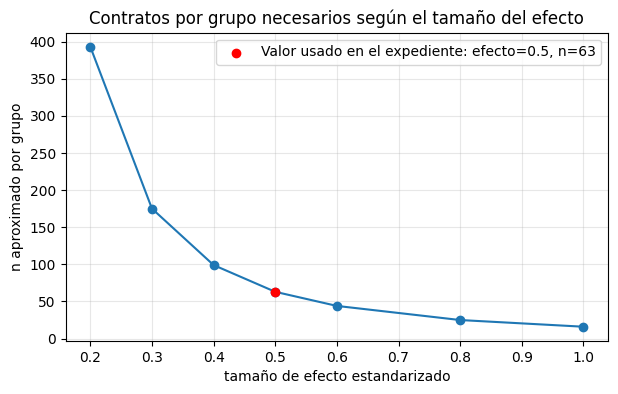

In [14]:
effect_sizes = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0])
n_por_efecto = np.ceil(2 * ((z_alpha + z_power) / effect_sizes) ** 2).astype(int)

plt.figure(figsize=(7, 4))
plt.plot(effect_sizes, n_por_efecto, marker="o")
plt.scatter([effect_size], [n_per_group], color="red", zorder=5,
            label=f"Valor usado en el expediente: efecto={effect_size}, n={n_per_group}")
plt.xlabel("tamaño de efecto estandarizado")
plt.ylabel("n aproximado por grupo")
plt.title("Contratos por grupo necesarios según el tamaño del efecto")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Antes de terminar

1. Si la diferencia de interés fuera más pequeña, ¿esperaría necesitar más o menos observaciones?
2. ¿Por qué disponer de muchas filas no corrige por sí solo un sesgo o una variable de confusión?
3. ¿Qué limitación de este expediente considera más importante después de completar la segunda semana?


### Respuestas a "Antes de terminar"

**1. Si la diferencia de interés fuera más pequeña, ¿esperaría necesitar más o menos observaciones?**
Más observaciones. El cálculo de potencia muestra que, con un tamaño de efecto estandarizado de 0,50, se necesitan aproximadamente 63 contratos por grupo para detectar la diferencia con una potencia del 80% (alpha = 0,05). Si la diferencia de interés fuera más pequeña (un tamaño de efecto menor), el numerador de la fórmula no cambia pero el denominador sí, por lo que `n_por_grupo` crece: se necesitan más contratos para poder distinguir una diferencia pequeña del ruido propio de la muestra.

**2. ¿Por qué disponer de muchas filas no corrige por sí solo un sesgo o una variable de confusión?**
Porque el tamaño de muestra reduce el error de muestreo (la variabilidad de una estimación de una muestra a otra), pero no corrige un error sistemático. El caso de Tona lo ilustra, aunque el recorte tuviera 500.000 filas en lugar de 50.000, si se sigue comparando a Tona contra la mediana general de todas las modalidades, la modalidad de régimen especial seguiría elevando artificialmente su valor mediano frente al resto. Más filas hacen que la estimación de "Tona vs. el resto" sea más precisa, pero siguen comparando cosas distintas (modalidades distintas); el sesgo por confusión solo se corrige cambiando el diseño de la comparación (por ejemplo, comparando dentro de la misma modalidad), no aumentando el volumen de datos.

**3. ¿Qué limitación de este expediente considera más importante después de completar la segunda semana?**
Que el caso investigado a fondo (Tona) tiene muy pocos contratos —solo 5 en todo el recorte—, por lo que su valor mediano depende de un puñado de observaciones y puede no ser estable: un solo contrato adicional (o uno menos) podría cambiar sustancialmente su posición frente a otras entidades. A esto se suma que el recorte corresponde a un único periodo y que solo se controló por modalidad de contratación; no se controló por tamaño o presupuesto de la entidad, que es un segundo factor de confusión plausible mencionado en la sección de causalidad.


## Actividad entregable

El entregable se construye a partir de la ejecución y el análisis de este notebook.

### Tablero de evidencia

Presente tres tarjetas. Cada una debe contener un hallazgo, la evidencia que lo sustenta, una interpretación posible y una duda pendiente. Las cifras deben poder localizarse en las salidas del notebook.

### Decisiones de preparación

Documente tres decisiones tomadas sobre la preparación de los datos. Para cada una indique el problema encontrado, el tratamiento aplicado, la evidencia que respalda la decisión y qué podría cambiar si esa decisión fuera incorrecta.

### Respuesta a la objeción y veredicto

Explique qué cambió después de incorporar la comparación de la segunda semana. El veredicto final debe ser uno de los siguientes:

- respaldada;
- parcialmente respaldada;
- no respaldada.

La conclusión debe incluir la principal limitación del análisis y una breve recomendación.

### Evidencia causal más fuerte

Explique qué diseño permitiría obtener evidencia causal más fuerte. Si un experimento aleatorizado no es viable, proponga una alternativa observacional o cuasi-experimental y justifique qué variable adicional sería necesario controlar.

### Declaración de uso de herramientas de inteligencia artificial

Indique la herramienta empleada, la actividad en la que se utilizó, el resultado que fue verificado y la forma de verificación, y una decisión del equipo que no se delegó a la herramienta.

El notebook entregado debe ejecutarse de principio a fin y reproducir las cifras utilizadas en el tablero y en el veredicto.


## Respuesta a la objeción y veredicto

**¿Qué cambió al incorporar la comparación de la segunda semana?**
Al separar por modalidad de contratación, el hallazgo de la primera semana se debilita. El Municipio de Tona tenía el valor mediano de contrato más alto del recorte (≈206 millones frente a 15 millones de mediana general), lo que lo hacía ver como la entidad más atípica. Pero Tona contrata exclusivamente bajo "Contratación régimen especial (con ofertas)", una modalidad que en todo el recorte ya tiene una mediana propia de $151,8 millones. Al comparar a Tona solo contra otras entidades que usan esa misma modalidad y tienen al menos 5 contratos, pasa del puesto 1 al puesto 6 de 32, por debajo del Hospital Universitario de Santander, la Piedecuestana de Servicios Públicos, el Municipio de Bucaramanga, el Departamento de Santander y el Instituto de Salud de Bucaramanga.

**Veredicto: parcialmente respaldada.**
Sí existen entidades con patrones contractuales distintos al resto (por ejemplo, la brecha entre número de contratos y valor total contratado entre Barrancabermeja, Bucaramanga y el Departamento de Santander, evidencia E2), pero el caso más llamativo de la primera semana —Tona— deja de destacar cuando se controla por modalidad de contratación, que es la variable de confusión más plausible. Esto muestra que no toda diferencia aparente justifica por sí sola una revisión adicional: primero hay que descartar que la diferencia se explique por la modalidad u otra característica estructural de la entidad.

**Principal limitación.**
El caso investigado a fondo (Tona) tiene solo 5 contratos en todo el recorte, así que su valor mediano depende de muy pocas observaciones y puede no ser estable. Además, el recorte corresponde a un único periodo y solo se controló por modalidad de contratación; no se controló por el tamaño o presupuesto de la entidad, un segundo factor de confusión plausible que podría explicar parte de la diferencia restante.

**Recomendación.**
Antes de priorizar una entidad para revisión con base en su valor mediano o su volumen de contratos, compararla siempre contra entidades de la misma modalidad y de tamaño o presupuesto similar, y verificar cuántos contratos sustentan esa cifra. Si son pocos (como en Tona), tratar el hallazgo como una hipótesis a validar con más periodos de datos, no como una conclusión.


## Evidencia causal más fuerte

**¿Por qué no es viable un experimento aleatorizado?**
La modalidad de contratación no la elige libremente la entidad ni un investigador: la determina la normativa de contratación pública colombiana según la cuantía y el objeto del contrato. Asignarla al azar violaría ese marco legal y no sería éticamente ni operativamente posible.

**Diseño alternativo propuesto.**
Un diseño observacional de pareo (matching): comparar contratos con características similares (mismo tipo de bien o servicio, presupuesto parecido) que, por las reglas de contratación, terminaron en modalidades distintas, y revisar si el valor difiere sistemáticamente entre esos pares. Grupo A: contratos bajo "Contratación régimen especial (con ofertas)". Grupo B: contratos equivalentes en tipo de bien/servicio y presupuesto, pero asignados mediante otra modalidad (por ejemplo, contratación directa). El resultado a medir sería el valor final del contrato (o su valor mediano), manteniendo fijo el tipo de bien o servicio y el tamaño del proyecto.

**Variable adicional que sería necesario controlar.**
El tamaño o presupuesto de la entidad. Una entidad pequeña que solo firma contratos de infraestructura grande puede mostrar un valor mediano alto sin que eso implique un comportamiento distinto al de sus pares; sin controlar por este factor, seguiría siendo difícil distinguir el efecto de la modalidad del efecto del tamaño de la entidad.


## Declaración de uso de herramientas de inteligencia artificial

**Herramienta empleada:** Claude (Anthropic), asistente de IA conversacional con ejecución de código sobre el notebook y la plantilla.

**Actividad en la que se empleó:** Apoyar la redacción del veredicto de la segunda semana y de la propuesta de evidencia causal, a partir de los resultados que el equipo ya había obtenido en el notebook.

**Resultado que fue verificado y forma de verificación:** Se contrastó cada cifra de las tres tarjetas (mediana de Tona = 205.963.000, mediana general de la modalidad = 151.772.200, mediana de contratación directa = 14.000.000; puesto 6 de 32, n ≈ 63 por grupo) contra las salidas impresas en las celdas correspondientes del notebook, confirmando que coinciden.

**Decisión del equipo que no se delegó a la herramienta:** Las hipótesis explicativas y dudas pendientes de cada tarjeta, y la interpretación de qué tan atípica sigue siendo Tona después de controlar por modalidad, fueron discutidas y decididas por el equipo antes de pedir la revisión; la IA solo verificó su consistencia con las salidas del notebook y ayudó a diligenciar el formato.
